In [11]:
import numpy as np
import pandas as pd
from torch import nn
from torchvision import transforms 
from torchvision import datasets 
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
import cv2
from PIL import Image
import sklearn



In [12]:

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),

    ])  
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),      
    transforms.RandomRotation(30),        
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),     
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    
])

In [13]:
#in_channels = 3 si image RGB 1 si image NB

In [14]:
trainData = datasets.ImageFolder(root="../data/train", transform=train_transform)
train_loader = DataLoader(trainData, batch_size=32, shuffle=True)
testData = datasets.ImageFolder(root="../data/test", transform=test_transform)
test_loader = DataLoader(testData, batch_size=32, shuffle=False)


In [15]:
# len(trainData) #nombre total d'images fi trainData
len(testData)
# len(train_loader) #nombre de groupes de 32 images (batches) fi train_loader

3956

In [16]:
class ConvNeuralNet(nn.Module) : 
    def __init__(self, num_classes = 2):
        super(ConvNeuralNet, self).__init__() 
        self.convoLayer1 = nn.Conv2d(3,16,3,stride=1) 
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.convoLayer2 = nn.Conv2d(16,32,3, stride=1)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.convoLayer3 = nn.Conv2d(32,64,3, stride=1)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(43264, 512)
        self.output = nn.Linear(512, num_classes) 
        #lvaleur l theny hwa nbr de classes de sortie
    def forward(self, x): 
        out = self.convoLayer1(x)
        out = self.relu(out)
        out = self.pool(out)
        out = self.convoLayer2(out)
        out = self.relu(out)
        out = self.pool(out)
        out = self.convoLayer3(out)
        out = self.relu(out)
        out = self.pool(out)
        out = self.flatten(out)
        # out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.output(out)
        return out
    

torch.Size([32, 3, 224, 224])
torch.Size([32])


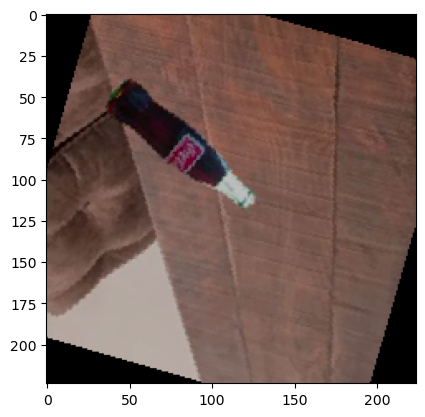

In [17]:
for images, labels in train_loader:
    print(images.shape)  
    print(labels.shape)   
    img = images[1 ]
    plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
    plt.show()
    break  

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model = ConvNeuralNet(num_classes=2) 
model = model.to(device) 
loss_fct = nn.CrossEntropyLoss() 
#optimoizer : bch naamlou update ll les poids mteena 3la 7asb taux d'erreur (loss function)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

In [ ]:
for j in range (20) : #9adeh men mara kol image bch ysirlha training (passage par tous les couches)
    for i, (images, labels) in enumerate(train_loader): #images heya x li f modéle
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images) 
        loss = loss_fct(outputs, labels)
        optimizer.zero_grad() #bch naamlou reset ll les gradients mteena
        loss.backward() #bch naamlou calcul ll les gradients mteena
        optimizer.step() #bch naamlou update ll les poids mteena 3
        print('Epoch [{}/{}], Loss: {:.4f}'.format(j+1, 32, loss.item()))

Epoch [1/32], Loss: 0.6912
Epoch [1/32], Loss: 7.3450
Epoch [1/32], Loss: 0.8575
Epoch [1/32], Loss: 2.2362
Epoch [1/32], Loss: 2.2741
Epoch [1/32], Loss: 0.6159
Epoch [1/32], Loss: 0.6548
Epoch [1/32], Loss: 0.8682
Epoch [1/32], Loss: 0.8219
Epoch [1/32], Loss: 0.8045
Epoch [1/32], Loss: 0.6885
Epoch [1/32], Loss: 0.6699
Epoch [1/32], Loss: 0.6629
Epoch [1/32], Loss: 0.6279
Epoch [1/32], Loss: 0.6467
Epoch [1/32], Loss: 0.6617
Epoch [1/32], Loss: 0.6389
Epoch [1/32], Loss: 0.6275
Epoch [1/32], Loss: 0.6352
Epoch [1/32], Loss: 0.5977
Epoch [1/32], Loss: 0.6113
Epoch [1/32], Loss: 0.5650
Epoch [1/32], Loss: 0.5844
Epoch [1/32], Loss: 0.4990
Epoch [1/32], Loss: 0.6123
Epoch [1/32], Loss: 0.6181
Epoch [1/32], Loss: 0.5562
Epoch [1/32], Loss: 0.5496
Epoch [1/32], Loss: 0.5720
Epoch [1/32], Loss: 0.5111
Epoch [1/32], Loss: 0.5846
Epoch [1/32], Loss: 0.5121
Epoch [1/32], Loss: 0.4535
Epoch [1/32], Loss: 0.5624
Epoch [1/32], Loss: 0.3333
Epoch [1/32], Loss: 0.4210
Epoch [1/32], Loss: 0.3737
E

c:\Users\LENOVO\anaconda3\envs\DigitalEyes\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/32], Loss: 0.3514
Epoch [1/32], Loss: 0.6385
Epoch [1/32], Loss: 0.5233
Epoch [1/32], Loss: 0.3901
Epoch [1/32], Loss: 0.4267
Epoch [1/32], Loss: 0.3121
Epoch [1/32], Loss: 0.3659
Epoch [1/32], Loss: 0.3811
Epoch [1/32], Loss: 0.2830
Epoch [1/32], Loss: 0.3143
Epoch [1/32], Loss: 0.2394
Epoch [1/32], Loss: 0.4639
Epoch [1/32], Loss: 0.3517
Epoch [1/32], Loss: 0.1619
Epoch [1/32], Loss: 0.1704
Epoch [1/32], Loss: 0.2409
Epoch [1/32], Loss: 0.1579
Epoch [1/32], Loss: 0.5990
Epoch [1/32], Loss: 0.1863
Epoch [1/32], Loss: 0.1551
Epoch [1/32], Loss: 0.3111
Epoch [1/32], Loss: 0.3072
Epoch [1/32], Loss: 0.2151
Epoch [1/32], Loss: 0.1742
Epoch [1/32], Loss: 0.4502
Epoch [1/32], Loss: 0.2036
Epoch [1/32], Loss: 0.2347
Epoch [1/32], Loss: 0.4345
Epoch [1/32], Loss: 0.2230
Epoch [1/32], Loss: 0.2007
Epoch [1/32], Loss: 0.3996
Epoch [1/32], Loss: 0.2068
Epoch [1/32], Loss: 0.2242
Epoch [1/32], Loss: 0.2357
Epoch [1/32], Loss: 0.1370
Epoch [1/32], Loss: 0.2826
Epoch [1/32], Loss: 0.1499
E

Testing

In [ ]:
with torch.no_grad(): #n7absou l training
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) #torch.max : bch naamlou calcul ll les predictions mteena , 1 maaneha chercher dans les colonnes
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(total) 
    print(correct)
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

6914
6666
Accuracy: 96.41%


In [ ]:
with torch.no_grad(): #n7absou l training
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) 
        total += labels.size(0) 
        correct += (predicted == labels).sum().item() 
    print(total)
    print(correct)
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

3448
3206
Accuracy: 92.98%


In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

with torch.no_grad():
    all_predictions = []
    all_labels = []
    
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    recall = recall_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions)

    print(f'Recall: {recall:.4f}')
    print(f'Precision: {precision:.4f}')


Recall: 0.8785
Precision: 0.9609


In [ ]:
torch.save(model.state_dict(), 'model.pth')

In [ ]:
myCNN = ConvNeuralNet(num_classes=2)

In [ ]:
myCNN.load_state_dict(torch.load('model.pth'))
myCNN.to(device)
#charger les poids du modéle d'aprés fichier 'model.pth'

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14956\3604404251.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myCNN.load_state_dict(torch.load('model.pth'))


ConvNeuralNet(
  (convoLayer1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convoLayer2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (convoLayer3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=43264, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=2, bias=True)
)

In [ ]:
myCNN.eval()

ConvNeuralNet(
  (convoLayer1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convoLayer2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (convoLayer3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=43264, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=2, bias=True)
)

In [ ]:
# cap = cv2.VideoCapture(0)  # 0 = your default webcam

# while True:
#     ret, frame = cap.read()
#     if not ret:  # ✅ Check if frame was captured successfully
#         break
    
#     image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#     image = Image.fromarray(image)
#     image = test_transform(image).unsqueeze(0).to(device)

#     with torch.no_grad():
#         outputs = myCNN(image)
#         _, predicted = torch.max(outputs, 1)
#         predicted_label = trainData.classes[predicted.item()]
    

#     cv2.putText(frame, predicted_label, (10, 30), 
#                 cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
#     cv2.imshow("Digital Eyes", frame)  # ✅ Actually display the frame
    
#     if cv2.waitKey(1) & 0xFF == ord('q'):  # ✅ Press Q to quit
#         break



import torch.nn.functional as F

# Now run the webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    image = Image.fromarray(image)
    image = train_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():  # ✅ indented inside the while loop
        outputs = myCNN(image)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

        predicted_label = trainData.classes[predicted.item()]

    cv2.putText(frame, predicted_label, (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    cv2.imshow("Digital Eyes", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    print(outputs)


cap.release()
cv2.destroyAllWindows()

tensor([[ 0.6704, -0.6318]], device='cuda:0')
tensor([[ 4.1794, -4.2283]], device='cuda:0')
tensor([[ 3.2605, -3.1801]], device='cuda:0')
tensor([[ 1.2714, -1.2173]], device='cuda:0')
tensor([[ 3.6862, -3.4728]], device='cuda:0')
tensor([[ 2.5416, -2.4463]], device='cuda:0')
tensor([[ 3.1375, -2.9511]], device='cuda:0')
tensor([[ 2.3489, -2.2673]], device='cuda:0')
tensor([[ 4.2720, -4.1644]], device='cuda:0')
tensor([[ 1.9364, -1.8339]], device='cuda:0')
tensor([[ 3.5110, -3.4841]], device='cuda:0')
tensor([[ 3.7690, -3.7985]], device='cuda:0')
tensor([[ 3.1372, -3.1619]], device='cuda:0')
tensor([[ 2.7327, -2.8143]], device='cuda:0')
tensor([[ 3.3197, -3.3391]], device='cuda:0')
tensor([[ 3.4314, -3.4852]], device='cuda:0')
tensor([[ 3.1507, -3.0601]], device='cuda:0')
tensor([[ 0.9482, -1.0164]], device='cuda:0')
tensor([[ 4.4019, -4.3116]], device='cuda:0')
tensor([[ 2.9879, -2.9340]], device='cuda:0')
tensor([[ 1.5504, -1.5270]], device='cuda:0')
tensor([[ 2.7804, -2.9114]], devic

In [ ]:
trainData.classes
trainData.class_to_idx



{'Soda': 0, 'WaterBottle': 1}

In [ ]:
image_path = "C:\\Users\\LENOVO\\Digital-Eyes\\CNNmodel\\fan.jpg"

def load_image(image_path):
    image = Image.open(image_path).convert('RGB')

    image = test_transform(image)
    return image.unsqueeze(0)  # Ajouter une dimension pour le batch

In [ ]:
import torchvision

image = load_image(image_path)
image = image.to(device)

myCNN.eval()

with torch.no_grad():
    outputs = myCNN(image)
    _, predicted = torch.max(outputs, 1)
    predicted_label = trainData.classes[predicted.item()]
    

print(predicted_label)
outputs


Soda


tensor([[ 3.4605, -3.4967]], device='cuda:0')

In [ ]:
 # raka7 l quality of images urtout f soda folder ++ erjaa l e5er disc maa claude

In [ ]:
testData.class_to_idx


{'SodaBottles': 0, 'WaterBottle': 1}

In [ ]:
import cv2

In [ ]:
# naamlou l hajet li similar kima milk juice // soda water // remote control phone // reading glasses sunglasses // 